In [2]:
# Cell 1: Configure VGG-style spectrogram experiment for Noisy Drone RF v2
import json
import math
import os
import re
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import torch
import yaml
import zipfile
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import mixed_precision
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Conv2D, Dense, Dropout, GlobalAveragePooling2D, Input, MaxPooling2D, SpatialDropout2D
from tensorflow.keras.models import Model, load_model

notebook_dir = Path().resolve()
if notebook_dir.name == 'notebooks':
    project_root = notebook_dir.parent
elif (notebook_dir / 'notebooks').exists() and (notebook_dir / 'src').exists():
    project_root = notebook_diro
elif (notebook_dir / 'ML-wireless-signal-classification').exists():
    project_root = notebook_dir / 'ML-wireless-signal-classification'
else:
    project_root = notebook_dir

cfg_path = project_root / 'configs' / 'local_data_paths.yaml'
if cfg_path.exists():
    local_cfg = yaml.safe_load(cfg_path.read_text())
    dcfg = local_cfg.get('datasets', {}).get('noisy_drone_rf_v2', {})
    data_dir = Path(
        dcfg.get(
            'data_dir',
            Path(local_cfg.get('dataset_root', '/scratch/rameyjm7/datasets')) / 'NoisyDroneRFv2',
        )
    )
else:
    data_dir = Path('/scratch/rameyjm7/datasets/NoisyDroneRFv2')

MAX_IQ_SAMPLES = int(os.getenv('NOISY_DRONE_MAX_IQ_SAMPLES', '1048576'))
MIN_SNR_DB = float(os.getenv('NOISY_DRONE_MIN_SNR_DB', '-6'))
DATA_FRACTION = float(os.getenv('NOISY_DRONE_DATA_FRACTION', '0.25'))
BATCH_SIZE = int(os.getenv('NOISY_DRONE_BATCH_SIZE', '8'))
SHUFFLE_BUFFER = int(os.getenv('NOISY_DRONE_SHUFFLE_BUFFER', '256'))
BURST_SMOOTH_SAMPLES = int(os.getenv('NOISY_DRONE_BURST_SMOOTH_SAMPLES', '512'))
REPLAY_BUFFER = os.getenv('NOISY_DRONE_REPLAY_BUFFER', '1').lower() not in {'0', 'false', 'no'}
REPLAY_SAMPLES_PER_CLASS = int(os.getenv('NOISY_DRONE_REPLAY_SAMPLES_PER_CLASS', '0'))
BALANCED_EVAL = os.getenv('NOISY_DRONE_BALANCED_EVAL', '1').lower() not in {'0', 'false', 'no'}
EVAL_LIMIT = int(os.getenv('NOISY_DRONE_EVAL_LIMIT', '0'))
SPEC_NFFT = int(os.getenv('NOISY_DRONE_SPEC_NFFT', '1024'))
SPEC_HOP = int(os.getenv('NOISY_DRONE_SPEC_HOP', '1024'))
SPEC_TIME_BINS = int(os.getenv('NOISY_DRONE_SPEC_TIME_BINS', '1024'))
SPEC_EVAL_WINDOWS = int(os.getenv('NOISY_DRONE_SPEC_EVAL_WINDOWS', '1'))
VGG_WEIGHT_DECAY = float(os.getenv('NOISY_DRONE_VGG_WEIGHT_DECAY', '1e-4'))
RANDOM_STATE = 1961

outputs_dir = project_root / 'outputs' / 'noisy_drone_rf_v2_eval'
model_dir = project_root / 'models' / 'noisy_drone_rf_v2'
default_cache_dir = Path('/scratch/rameyjm7/ML-wireless-signal-classification/cache/noisy_drone_rf_v2/spectrogram_full_complex_cache')
cache_dir = Path(os.getenv('NOISY_DRONE_SPEC_CACHE_DIR', str(default_cache_dir)))
outputs_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)
cache_dir.mkdir(parents=True, exist_ok=True)

print('Project root:', project_root)
print('Dataset:', data_dir)
print('Spectrogram cache:', cache_dir)
print('VGG full-capture complex spectrogram bins:', SPEC_NFFT, 'x', SPEC_TIME_BINS)
print('Eval windows:', SPEC_EVAL_WINDOWS)
print('Min SNR:', MIN_SNR_DB, 'Data fraction:', DATA_FRACTION)
assert data_dir.exists(), f'Missing dataset directory: {data_dir}'

sample_re = re.compile(r'IQdata_sample(?P<sample>\d+)_target(?P<target>-?\d+)_snr(?P<snr>-?\d+)\.pt$')
pt_files = sorted(data_dir.rglob('IQdata_sample*_target*_snr*.pt'))
assert pt_files, f'No matching .pt files found under {data_dir}'

class_stats_path = data_dir / 'class_stats.csv'
class_stats = pd.read_csv(class_stats_path) if class_stats_path.exists() else None
rows = []
for filepath in pt_files:
    match = sample_re.search(filepath.name)
    if not match:
        continue
    rows.append({
        'filepath': str(filepath),
        'sample_id': int(match.group('sample')),
        'target_raw': int(match.group('target')),
        'snr': int(match.group('snr')),
    })

data_df = pd.DataFrame(rows).sort_values('sample_id').reset_index(drop=True)
full_sample_count = len(data_df)
if MIN_SNR_DB > -999:
    data_df = data_df[data_df['snr'] >= MIN_SNR_DB].reset_index(drop=True)
if DATA_FRACTION < 1.0:
    data_df = (
        data_df.groupby('target_raw', group_keys=False)
        .sample(frac=DATA_FRACTION, random_state=RANDOM_STATE)
        .sort_values('sample_id')
        .reset_index(drop=True)
    )

classes = np.array(sorted(data_df['target_raw'].unique()), dtype=np.int64)
class_to_index = {int(c): idx for idx, c in enumerate(classes)}
if class_stats is not None and {'class_int', 'class'}.issubset(class_stats.columns):
    class_name_lookup = dict(zip(class_stats['class_int'].astype(int), class_stats['class'].astype(str)))
else:
    class_name_lookup = {int(c): f'target_{int(c)}' for c in classes}
label_names = [class_name_lookup.get(int(c), f'target_{int(c)}') for c in classes]
data_df['label_idx'] = data_df['target_raw'].map(class_to_index).astype(np.int64)
data_df['sample_weight'] = 1.0
SNR_SCALE = max(float(data_df['snr'].abs().max()), 1.0)

print('Samples selected:', len(data_df), '/', full_sample_count)
print('Class names:', label_names)
print('Class counts:', data_df['label_idx'].value_counts().sort_index().to_dict())


def load_pt_iq(filepath):
    obj = torch.load(filepath, map_location='cpu')

    def extract_iq(value):
        if isinstance(value, dict):
            for key in ('x_iq', 'iq', 'IQ', 'x', 'X', 'data', 'samples'):
                if key in value:
                    return extract_iq(value[key])
            raise KeyError(f'No IQ tensor key found in {filepath}; keys={list(value.keys())}')
        if isinstance(value, (tuple, list)):
            if not value:
                raise ValueError(f'Empty sequence in {filepath}')
            return extract_iq(value[0])
        return value

    obj = extract_iq(obj)
    arr = obj.detach().cpu().numpy() if hasattr(obj, 'detach') else np.asarray(obj)
    arr = np.squeeze(arr)
    if arr.ndim == 1:
        if np.iscomplexobj(arr):
            arr = np.stack([arr.real, arr.imag], axis=-1)
        else:
            assert arr.size % 2 == 0, f'Cannot infer IQ pairs from shape {arr.shape} in {filepath}'
            arr = arr.reshape(-1, 2)
    elif arr.ndim == 2:
        if arr.shape[0] == 2 and arr.shape[1] != 2:
            arr = arr.T
        elif arr.shape[-1] != 2:
            raise ValueError(f'Expected IQ tensor with final dimension 2, got {arr.shape} in {filepath}')
    else:
        if arr.shape[-1] == 2:
            arr = arr.reshape(-1, 2)
        elif arr.shape[0] == 2:
            arr = np.moveaxis(arr, 0, -1).reshape(-1, 2)
        else:
            raise ValueError(f'Expected IQ tensor with two channels, got {arr.shape} in {filepath}')
    return np.asarray(arr, dtype=np.float32)

raw_sample_len = load_pt_iq(data_df.iloc[0]['filepath']).shape[0]
SAMPLE_LEN = min(raw_sample_len, MAX_IQ_SAMPLES)
num_classes = len(classes)
input_shape = (SPEC_NFFT, SPEC_TIME_BINS, 2)
print('Raw sample length:', raw_sample_len)
print('VGG full-capture complex-STFT input shape:', input_shape)


def find_burst_start(x, window_len):
    if x.shape[0] <= window_len:
        return 0
    power = np.mean(np.square(x.astype(np.float32)), axis=1)
    smooth_len = max(1, min(BURST_SMOOTH_SAMPLES, power.shape[0] // 8))
    if smooth_len > 1:
        kernel = np.ones(smooth_len, dtype=np.float32) / float(smooth_len)
        power = np.convolve(power, kernel, mode='same')
    peak = int(np.argmax(power))
    return int(np.clip(peak - window_len // 2, 0, x.shape[0] - window_len))


def normalize_iq_window(window):
    window = window.astype(np.float32, copy=False)
    return window / (np.max(np.abs(window)) + 1e-8)


def resize_time_axis(spec, target_bins):
    current = spec.shape[1]
    if current == target_bins:
        return spec
    if current > target_bins:
        idx = np.linspace(0, current - 1, target_bins).round().astype(int)
        return spec[:, idx]
    return np.pad(spec, ((0, 0), (0, target_bins - current)), mode='edge')


def iq_window_to_spectrogram(iq, snr_value):
    # Complex STFT representation: channel 0 is real FFT, channel 1 is imaginary FFT.
    # This preserves phase-sensitive structure that log-magnitude spectrograms discard.
    iq = normalize_iq_window(iq[:, :2])
    complex_iq = iq[:, 0].astype(np.float32) + 1j * iq[:, 1].astype(np.float32)
    if len(complex_iq) < SPEC_NFFT:
        complex_iq = np.pad(complex_iq, (0, SPEC_NFFT - len(complex_iq)), mode='constant')
    starts = np.arange(0, len(complex_iq) - SPEC_NFFT + 1, SPEC_HOP)
    if starts.size == 0:
        starts = np.array([0])
    window = np.hanning(SPEC_NFFT).astype(np.float32)
    frames = np.stack([complex_iq[s:s + SPEC_NFFT] * window for s in starts], axis=0)
    fft_complex = np.fft.fftshift(np.fft.fft(frames, n=SPEC_NFFT, axis=1), axes=1).T
    fft_complex = fft_complex / float(SPEC_NFFT)
    real_part = resize_time_axis(fft_complex.real.astype(np.float32), SPEC_TIME_BINS)
    imag_part = resize_time_axis(fft_complex.imag.astype(np.float32), SPEC_TIME_BINS)
    spec = np.stack([real_part, imag_part], axis=-1).astype(np.float32)
    spec = spec / (np.std(spec) + 1e-6)
    spec = np.clip(spec, -6.0, 6.0).astype(np.float32)
    return spec


def spectrogram_cache_path(filepath, snr_value):
    src = Path(str(filepath))
    name = f'{src.stem}_full_complex_len{SAMPLE_LEN}_nfft{SPEC_NFFT}_hop{SPEC_HOP}_tb{SPEC_TIME_BINS}_snr{int(float(snr_value))}.npz'
    return cache_dir / name


def safe_load_cached_spectrogram(cache_path):
    try:
        with np.load(cache_path) as data:
            x = data['x'].astype(np.float32)
        if x.shape != input_shape:
            raise ValueError(f'cached shape {x.shape} != expected {input_shape}')
        if not np.isfinite(x).all():
            raise ValueError('cached spectrogram contains NaN or Inf')
        return x
    except (EOFError, OSError, ValueError, KeyError, zipfile.BadZipFile) as exc:
        print(f'Removing corrupt spectrogram cache: {cache_path} ({type(exc).__name__}: {exc})')
        try:
            Path(cache_path).unlink(missing_ok=True)
        except OSError as unlink_exc:
            print(f'Warning: could not remove corrupt cache {cache_path}: {unlink_exc}')
        return None


def write_spectrogram_cache_atomic(cache_path, x):
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = cache_path.with_suffix(cache_path.suffix + f'.tmp_{os.getpid()}')
    try:
        np.savez_compressed(tmp_path, x=x.astype(np.float32))
        generated_path = tmp_path if tmp_path.exists() else Path(str(tmp_path) + '.npz')
        generated_path.replace(cache_path)
    finally:
        tmp_path.unlink(missing_ok=True)
        Path(str(tmp_path) + '.npz').unlink(missing_ok=True)


def prepare_spectrogram(filepath, snr_value):
    cache_path = spectrogram_cache_path(filepath, snr_value)
    if cache_path.exists():
        cached = safe_load_cached_spectrogram(cache_path)
        if cached is not None:
            return cached
    x_full = load_pt_iq(filepath)
    if x_full.shape[0] < SAMPLE_LEN:
        x_full = np.pad(x_full, ((0, SAMPLE_LEN - x_full.shape[0]), (0, 0)), mode='constant')
    start = find_burst_start(x_full, SAMPLE_LEN)
    x = iq_window_to_spectrogram(x_full[start:start + SAMPLE_LEN, :2], snr_value)
    write_spectrogram_cache_atomic(cache_path, x)
    return x.astype(np.float32)


def prepare_spectrogram_windows(filepath, snr_value, n_windows=None):
    n_windows = SPEC_EVAL_WINDOWS if n_windows is None else int(n_windows)
    if n_windows <= 1:
        return prepare_spectrogram(filepath, snr_value)[None, ...]
    x_full = load_pt_iq(filepath)
    if x_full.shape[0] < SAMPLE_LEN:
        x_full = np.pad(x_full, ((0, SAMPLE_LEN - x_full.shape[0]), (0, 0)), mode='constant')
    center_start = find_burst_start(x_full, SAMPLE_LEN)
    if x_full.shape[0] <= SAMPLE_LEN:
        starts = [0]
    else:
        stride = max(1, SAMPLE_LEN // max(4, n_windows + 1))
        offsets = (np.arange(n_windows) - ((n_windows - 1) / 2.0)) * stride
        starts = [int(np.clip(center_start + off, 0, x_full.shape[0] - SAMPLE_LEN)) for off in offsets]
        starts = sorted(set(starts))
    return np.stack([iq_window_to_spectrogram(x_full[start:start + SAMPLE_LEN, :2], snr_value) for start in starts], axis=0).astype(np.float32)


def make_balanced_replay_df(split_df, samples_per_class=0):
    counts = split_df['label_idx'].value_counts().sort_index()
    target_n = int(samples_per_class) if samples_per_class > 0 else int(counts.max())
    parts = []
    for label_idx, group in split_df.groupby('label_idx', sort=True):
        parts.append(group.sample(n=target_n, replace=len(group) < target_n, random_state=RANDOM_STATE + int(label_idx)))
    return pd.concat(parts).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)


def make_balanced_eval_df(split_df):
    target_n = int(split_df['label_idx'].value_counts().min())
    return split_df.groupby('label_idx', group_keys=False).sample(n=target_n, random_state=RANDOM_STATE).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

idx = np.arange(len(data_df))
train_idx, test_idx = train_test_split(idx, test_size=0.20, random_state=RANDOM_STATE, stratify=data_df['label_idx'])
train_idx, val_idx = train_test_split(train_idx, test_size=0.20, random_state=RANDOM_STATE, stratify=data_df.iloc[train_idx]['label_idx'])
train_df = data_df.iloc[train_idx].reset_index(drop=True)
val_df = data_df.iloc[val_idx].reset_index(drop=True)
test_df = data_df.iloc[test_idx].reset_index(drop=True)
train_fit_df = make_balanced_replay_df(train_df, REPLAY_SAMPLES_PER_CLASS) if REPLAY_BUFFER else train_df.copy()
balanced_test_df = make_balanced_eval_df(test_df) if BALANCED_EVAL else None

manifest_path = outputs_dir / '33_noisy_drone_rf_v2_vgg_full_complex_replay_manifest.csv'
train_fit_df[['filepath', 'sample_id', 'target_raw', 'label_idx', 'snr']].to_csv(manifest_path, index=False)
print('Train source counts:', train_df['label_idx'].value_counts().sort_index().to_dict())
print('Train replay counts:', train_fit_df['label_idx'].value_counts().sort_index().to_dict())
print('Test natural counts:', test_df['label_idx'].value_counts().sort_index().to_dict())
if balanced_test_df is not None:
    print('Test balanced counts:', balanced_test_df['label_idx'].value_counts().sort_index().to_dict())
print('Replay manifest:', manifest_path)


def make_generator(split_df):
    records = split_df[['filepath', 'snr', 'label_idx', 'sample_weight']].to_records(index=False)

    def gen():
        for filepath, snr_value, label_idx, sample_weight in records:
            yield prepare_spectrogram(filepath, snr_value), np.int64(label_idx), np.float32(sample_weight)
    return gen


def make_dataset(split_df, shuffle=False, repeat=False):
    ds = tf.data.Dataset.from_generator(
        make_generator(split_df),
        output_signature=(
            tf.TensorSpec(shape=input_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int64),
            tf.TensorSpec(shape=(), dtype=tf.float32),
        ),
    )
    if shuffle:
        ds = ds.shuffle(min(len(split_df), SHUFFLE_BUFFER), seed=RANDOM_STATE, reshuffle_each_iteration=True)
    if repeat:
        ds = ds.repeat()
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_fit_df, shuffle=True, repeat=True)
val_ds = make_dataset(val_df, shuffle=False, repeat=True)
test_ds = make_dataset(test_df, shuffle=False, repeat=False)
train_steps = int(math.ceil(len(train_fit_df) / BATCH_SIZE))
validation_steps = int(math.ceil(len(val_df) / BATCH_SIZE))
test_steps = int(math.ceil(len(test_df) / BATCH_SIZE))
print('Steps:', train_steps, validation_steps, test_steps)

mixed_precision.set_global_policy('mixed_float16')


def vgg_block(x, filters, blocks, block_name, dropout_rate):
    regularizer = tf.keras.regularizers.l2(VGG_WEIGHT_DECAY)
    for i in range(blocks):
        x = Conv2D(
            filters,
            (3, 3),
            padding='same',
            activation='relu',
            kernel_regularizer=regularizer,
            name=f'{block_name}_conv{i + 1}',
        )(x)
        x = BatchNormalization(name=f'{block_name}_bn{i + 1}')(x)
    x = MaxPooling2D((2, 2), name=f'{block_name}_pool')(x)
    x = SpatialDropout2D(dropout_rate, name=f'{block_name}_spatial_dropout')(x)
    return x


def build_vgg_spectrogram(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = vgg_block(inputs, 32, 2, 'block1', 0.08)
    x = vgg_block(x, 64, 2, 'block2', 0.12)
    x = vgg_block(x, 128, 3, 'block3', 0.18)
    x = vgg_block(x, 192, 3, 'block4', 0.24)
    x = Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(VGG_WEIGHT_DECAY), name='block5_conv1')(x)
    x = BatchNormalization(name='block5_bn1')(x)
    x = SpatialDropout2D(0.30, name='block5_spatial_dropout')(x)
    x = GlobalAveragePooling2D(name='vgg_spectrogram_embedding')(x)
    x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(VGG_WEIGHT_DECAY), name='fc1')(x)
    x = Dropout(0.55, name='fc1_dropout')(x)
    x = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(VGG_WEIGHT_DECAY), name='fc2')(x)
    x = Dropout(0.45, name='fc2_dropout')(x)
    outputs = Dense(num_classes, activation='softmax', dtype='float32', name='predictions')(x)
    model = Model(inputs, outputs, name='noisy_drone_rf_v2_vgg_full_complex_spectrogram')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1.5e-4, clipnorm=1.0),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

vgg_model = build_vgg_spectrogram(input_shape, num_classes)
print('VGG weight decay:', VGG_WEIGHT_DECAY)
vgg_model.summary()


I0000 00:00:1782562910.495446 2758659 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782562910.535680 2758659 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782562915.344820 2758659 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Project root: /home/rameyjm7/workspace/ML-wireless-signal-classification
Dataset: /scratch/rameyjm7/datasets/NoisyDroneRFv2
Spectrogram cache: /scratch/rameyjm7/ML-wireless-signal-classification/cache/noisy_drone_rf_v2/spectrogram_full_complex_cache
VGG full-capture complex spectrogram bins: 1024 x 1024
Eval windows: 1
Min SNR: -6.0 Data fraction: 0.25
Samples selected: 3242 / 17744
Class names: ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Noise', 'Taranis', 'Turnigy']
Class counts: {0: 236, 1: 635, 2: 148, 3: 144, 4: 1622, 5: 300, 6: 157}
Raw sample length: 1048576
VGG full-capture complex-STFT input shape: (1024, 1024, 2)
Train source counts: {0: 151, 1: 406, 2: 94, 3: 92, 4: 1038, 5: 192, 6: 101}
Train replay counts: {0: 1038, 1: 1038, 2: 1038, 3: 1038, 4: 1038, 5: 1038, 6: 1038}
Test natural counts: {0: 47, 1: 127, 2: 30, 3: 29, 4: 325, 5: 60, 6: 31}
Test balanced counts: {0: 29, 1: 29, 2: 29, 3: 29, 4: 29, 5: 29, 6: 29}
Replay manifest: /home/rameyjm7/workspace/ML-wireless-signal

I0000 00:00:1782562929.262061 2758659 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 938 MB memory:  -> device: 0, name: NVIDIA H200, pci bus id: 0000:19:00.0, compute capability: 9.0a
E0000 00:00:1782562929.431428 2760770 ptx_compiler_helpers.cc:154] *** WARNING *** Invoking ptxas with version 12.6.20, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


Steps: 909 65 82
VGG weight decay: 0.0001


Model: "noisy_drone_rf_v2_vgg_full_complex_spectrogram"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1024, 1024, 2)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 1024, 1024, 32) │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 1024, 1024, 32) │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 1024, 1024, 32) │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 1024, 1024, 32) │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 512, 512, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_spatial_dropout          │ (None, 512, 512, 32)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 512, 512, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 512, 512, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 512, 512, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 512, 512, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_spatial_dropout          │ (None, 256, 256, 64)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 256, 256, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 256, 256, 128)  │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 256, 256, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 256, 256, 128)  │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 256, 256, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn3 (BatchNormalization) │ (None, 256, 256, 128)  │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_spatial_dropout          │ (None, 128, 128, 128)  │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 128, 128, 192)  │       221,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_bn1 (BatchNormalization) │ (None, 128, 128, 192)  │           768 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,867,463 (7.12 MB)

 Trainable params: 1,864,647 (7.11 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [2]:
# Cell 2: Continue training and checkpoint the VGG-style spectrogram model
vgg_best_path = model_dir / 'noisy_drone_rf_v2_vgg_full_complex_spectrogram_best.keras'
vgg_final_path = model_dir / 'noisy_drone_rf_v2_vgg_full_complex_spectrogram_final.keras'
vgg_history_path = model_dir / 'noisy_drone_rf_v2_vgg_full_complex_spectrogram_history.json'
vgg_history_csv_path = model_dir / 'noisy_drone_rf_v2_vgg_full_complex_spectrogram_training_history.csv'

resume_path = None
if vgg_final_path.exists():
    resume_path = vgg_final_path
elif vgg_best_path.exists():
    resume_path = vgg_best_path

if resume_path is not None:
    print('Attempting to resume VGG training from:', resume_path)
    try:
        loaded_model = load_model(resume_path, compile=False)
        if tuple(loaded_model.input_shape[1:]) != tuple(input_shape):
            print('Checkpoint input shape does not match current complex-STFT shape:', loaded_model.input_shape, '!=', input_shape)
            print('Starting fresh complex-STFT VGG model instead.')
            resume_path = None
        else:
            vgg_model = loaded_model
            print('Resuming VGG training from compatible checkpoint:', resume_path)
    except Exception as exc:
        print('Could not load checkpoint; starting fresh. Error:', repr(exc))
        resume_path = None

if resume_path is not None:
    vgg_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=float(os.getenv('NOISY_DRONE_VGG_CONTINUE_LR', '5e-5')),
            clipnorm=1.0,
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
else:
    print('Starting VGG training from fresh model.')

class ValidationMacroF1(tf.keras.callbacks.Callback):
    def __init__(self, validation_frame, eval_windows=1, max_samples=0):
        super().__init__()
        self.validation_frame = validation_frame.head(max_samples).copy() if max_samples > 0 else validation_frame.copy()
        self.eval_windows = int(eval_windows)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        y_true = self.validation_frame['label_idx'].to_numpy(dtype=np.int64)
        y_pred = []
        for row in self.validation_frame.itertuples(index=False):
            x = prepare_spectrogram_windows(row.filepath, row.snr, n_windows=self.eval_windows)
            probs = self.model.predict(x, batch_size=BATCH_SIZE, verbose=0).mean(axis=0)
            y_pred.append(int(np.argmax(probs)))
        macro_f1 = float(f1_score(y_true, np.asarray(y_pred), average='macro', zero_division=0))
        logs['val_macro_f1'] = macro_f1
        print(f' - val_macro_f1: {macro_f1:.4f}')

# No EarlyStopping here: rerun this cell to continue from the last saved final model.
callbacks = [
    ValidationMacroF1(
        val_df,
        eval_windows=int(os.getenv('NOISY_DRONE_VGG_VAL_METRIC_WINDOWS', '1')),
        max_samples=int(os.getenv('NOISY_DRONE_VGG_VAL_METRIC_LIMIT', '0')),
    ),
    ModelCheckpoint(vgg_best_path, monitor='val_macro_f1', mode='max', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
]

existing_history_df = pd.read_csv(vgg_history_csv_path) if vgg_history_csv_path.exists() else pd.DataFrame()
last_global_epoch = int(existing_history_df['global_epoch'].max()) if not existing_history_df.empty else 0
run_id = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
run_epochs = int(os.getenv('NOISY_DRONE_VGG_EPOCHS', '50'))

history = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=run_epochs,
    steps_per_epoch=train_steps,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1,
)

# Always save the latest continuation point. The best checkpoint is also maintained separately.
vgg_model.save(vgg_final_path)

n_epochs = len(next(iter(history.history.values()))) if history.history else 0
history_rows = []
for epoch_idx in range(n_epochs):
    row = {
        'run_id': run_id,
        'epoch': epoch_idx + 1,
        'global_epoch': last_global_epoch + epoch_idx + 1,
        'resumed_from': str(resume_path) if resume_path is not None else '',
        'data_fraction': float(DATA_FRACTION),
        'sample_len': int(SAMPLE_LEN),
        'batch_size': int(BATCH_SIZE),
        'train_fit_samples': int(len(train_fit_df)),
    }
    for metric_name, metric_values in history.history.items():
        row[metric_name] = float(metric_values[epoch_idx])
    history_rows.append(row)

run_history_df = pd.DataFrame(history_rows)
combined_history_df = pd.concat([existing_history_df, run_history_df], ignore_index=True) if not existing_history_df.empty else run_history_df
combined_history_df.to_csv(vgg_history_csv_path, index=False)

best_metric_source = combined_history_df if not combined_history_df.empty else run_history_df
best_metric_name = 'val_macro_f1' if 'val_macro_f1' in best_metric_source else 'val_accuracy'
if best_metric_name in best_metric_source and not best_metric_source.empty:
    best_row = best_metric_source.loc[best_metric_source[best_metric_name].idxmax()]
    best_global_epoch = int(best_row['global_epoch'])
    best_val_accuracy = float(best_row['val_accuracy']) if 'val_accuracy' in best_row else float('nan')
    best_val_macro_f1 = float(best_row['val_macro_f1']) if 'val_macro_f1' in best_row else None
else:
    best_global_epoch = int(last_global_epoch + n_epochs)
    best_val_accuracy = float('nan')
    best_val_macro_f1 = None

payload = {
    'history': history.history,
    'run_id': run_id,
    'run_epochs': int(run_epochs),
    'resumed_from': str(resume_path) if resume_path is not None else None,
    'last_global_epoch': int(last_global_epoch + n_epochs),
    'best_global_epoch': best_global_epoch,
    'best_val_accuracy': best_val_accuracy,
    'best_val_macro_f1': best_val_macro_f1,
    'best_metric_name': best_metric_name,
    'history_csv_path': str(vgg_history_csv_path),
    'config': {
        'sample_len': int(SAMPLE_LEN),
        'input_shape': list(input_shape),
        'num_classes': int(num_classes),
        'label_names': label_names,
        'data_fraction': float(DATA_FRACTION),
        'min_snr_db': float(MIN_SNR_DB),
        'nfft': int(SPEC_NFFT),
        'hop': int(SPEC_HOP),
        'time_bins': int(SPEC_TIME_BINS),
        'eval_windows': int(SPEC_EVAL_WINDOWS),
        'weight_decay': float(VGG_WEIGHT_DECAY),
        'representation': 'full_capture_complex_stft_real_imag',
        'train_fit_samples': int(len(train_fit_df)),
        'train_replay_counts': {str(k): int(v) for k, v in train_fit_df['label_idx'].value_counts().sort_index().items()},
    },
}
vgg_history_path.write_text(json.dumps(payload, indent=2))
print('Saved best checkpoint:', vgg_best_path)
print('Saved latest continuation model:', vgg_final_path)
print('Saved latest run history:', vgg_history_path)
print('Saved cumulative history CSV:', vgg_history_csv_path)
print('Last global epoch:', last_global_epoch + n_epochs)
print('Best global epoch:', best_global_epoch, 'best metric:', best_metric_name, 'best val_accuracy:', best_val_accuracy)
if best_val_macro_f1 is not None:
    print('Best val_macro_f1:', best_val_macro_f1)


Attempting to resume VGG training from: /home/rameyjm7/workspace/ML-wireless-signal-classification/models/noisy_drone_rf_v2/noisy_drone_rf_v2_vgg_full_complex_spectrogram_best.keras
Resuming VGG training from compatible checkpoint: /home/rameyjm7/workspace/ML-wireless-signal-classification/models/noisy_drone_rf_v2/noisy_drone_rf_v2_vgg_full_complex_spectrogram_best.keras
Epoch 1/50


I0000 00:00:1782511703.427630  512901 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1782511713.432433  512901 shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 171 of 256
I0000 00:00:1782511718.413080  512901 shuffle_dataset_op.cc:483] Shuffle buffer filled.
I0000 00:00:1782511718.856042  512725 service.cc:153] XLA service 0x15507004d680 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782511718.856080  512725 service.cc:161]   StreamExecutor [0]: NVIDIA A100-SXM4-80GB, Compute Capability 8.0 (Driver: 13.0.0; Runtime: 12.6.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1782511719.031411  512725 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782511721.154903  512725 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1782511721.605110  5

  2/909 ━━━━━━━━━━━━━━━━━━━━ 1:00 66ms/step - accuracy: 0.3438 - loss: 1.6426    

I0000 00:00:1782511836.762311  512725 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


909/909 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.4536 - loss: 1.4119 - val_macro_f1: 0.6561

Epoch 1: val_macro_f1 improved from None to 0.65612, saving model to /home/rameyjm7/workspace/ML-wireless-signal-classification/models/noisy_drone_rf_v2/noisy_drone_rf_v2_vgg_full_complex_spectrogram_best.keras

Epoch 1: finished saving model to /home/rameyjm7/workspace/ML-wireless-signal-classification/models/noisy_drone_rf_v2/noisy_drone_rf_v2_vgg_full_complex_spectrogram_best.keras
909/909 ━━━━━━━━━━━━━━━━━━━━ 666s 580ms/step - accuracy: 0.4882 - loss: 1.3590 - val_accuracy: 0.8058 - val_loss: 0.8951 - val_macro_f1: 0.6561 - learning_rate: 5.0000e-05
Epoch 2/50
909/909 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.5486 - loss: 1.2351 - val_macro_f1: 0.6869

Epoch 2: val_macro_f1 improved from 0.65612 to 0.68689, saving model to /home/rameyjm7/workspace/ML-wireless-signal-classification/models/noisy_drone_rf_v2/noisy_drone_rf_v2_vgg_full_complex_spectrogram_best.keras

Epoch 2: fin

KeyboardInterrupt: 

VGG full-complex spectrogram natural report (1 eval windows)
accuracy: 0.9768875192604006
              precision    recall  f1-score   support

         DJI       0.98      0.89      0.93        47
   FutabaT14       1.00      0.94      0.97       127
    FutabaT7       1.00      1.00      1.00        30
    Graupner       0.97      1.00      0.98        29
       Noise       0.96      1.00      0.98       325
     Taranis       1.00      0.95      0.97        60
     Turnigy       1.00      1.00      1.00        31

    accuracy                           0.98       649
   macro avg       0.99      0.97      0.98       649
weighted avg       0.98      0.98      0.98       649

Saved: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/noisy_drone_rf_v2_eval/33_noisy_drone_rf_v2_vgg_full_complex_spectrogram_confusion_matrix.png


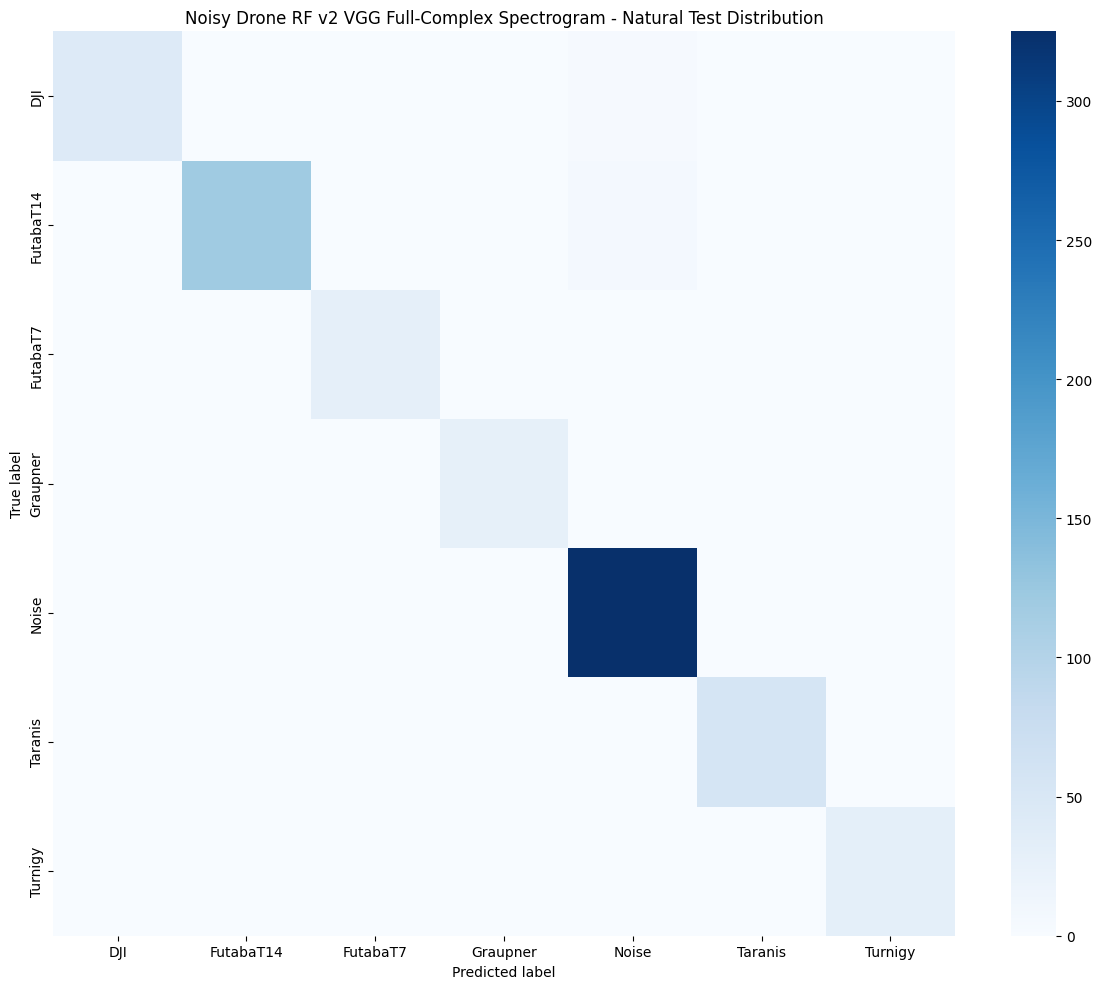

VGG full-complex spectrogram balanced report (1 eval windows)
accuracy: 0.9802955665024631
              precision    recall  f1-score   support

         DJI       1.00      0.93      0.96        29
   FutabaT14       1.00      0.97      0.98        29
    FutabaT7       1.00      1.00      1.00        29
    Graupner       1.00      1.00      1.00        29
       Noise       0.88      1.00      0.94        29
     Taranis       1.00      0.97      0.98        29
     Turnigy       1.00      1.00      1.00        29

    accuracy                           0.98       203
   macro avg       0.98      0.98      0.98       203
weighted avg       0.98      0.98      0.98       203

Saved: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/noisy_drone_rf_v2_eval/33_noisy_drone_rf_v2_vgg_full_complex_spectrogram_balanced_confusion_matrix.png


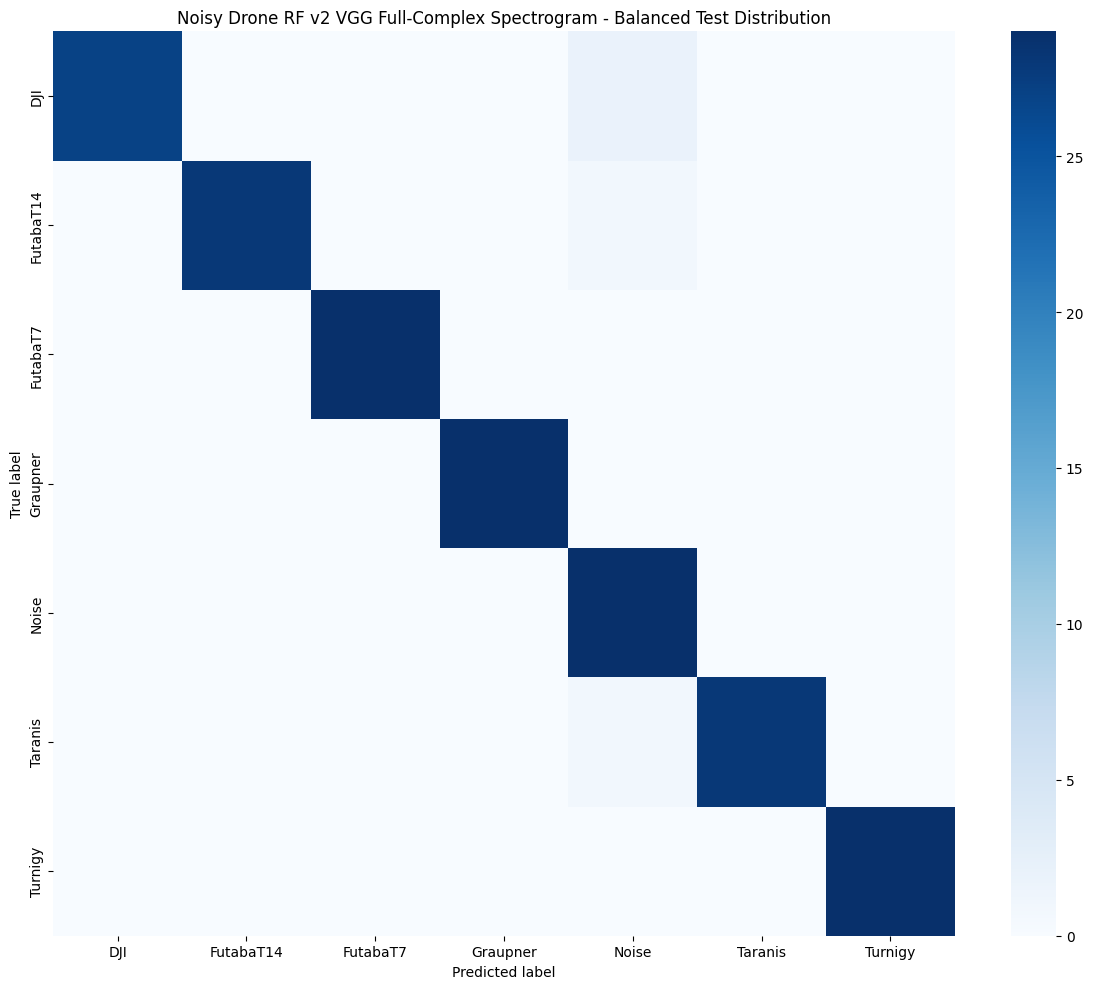

Saved metrics: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/noisy_drone_rf_v2_eval/33_noisy_drone_rf_v2_vgg_full_complex_spectrogram_metrics.json


In [3]:
# Cell 3: Evaluate the VGG-style spectrogram model with multi-window averaging
vgg_eval_model = load_model(vgg_final_path if vgg_final_path.exists() else vgg_best_path, compile=False)


def predict_vgg(split_df, eval_windows=None):
    if EVAL_LIMIT > 0:
        split_df = split_df.head(EVAL_LIMIT).copy()
    probs = []
    for row in split_df.itertuples(index=False):
        x = prepare_spectrogram_windows(row.filepath, row.snr, n_windows=eval_windows)
        window_probs = vgg_eval_model.predict(x, batch_size=BATCH_SIZE, verbose=0)
        probs.append(window_probs.mean(axis=0))
    return split_df, np.asarray(probs, dtype=np.float32)

natural_eval_df, natural_probs = predict_vgg(test_df)
y_true = natural_eval_df['label_idx'].to_numpy(dtype=np.int64)
y_pred = natural_probs.argmax(axis=1)
print(f'VGG full-complex spectrogram natural report ({SPEC_EVAL_WINDOWS} eval windows)')
print('accuracy:', accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

metrics = {
    'model': 'vgg_spectrogram',
    'eval_windows': int(SPEC_EVAL_WINDOWS),
    'natural_accuracy': float(accuracy_score(y_true, y_pred)),
    'natural_macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
    'natural_weighted_f1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
}

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=np.arange(num_classes)), cmap='Blues', xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_title('Noisy Drone RF v2 VGG Full-Complex Spectrogram - Natural Test Distribution')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
cm_path = outputs_dir / '33_noisy_drone_rf_v2_vgg_full_complex_spectrogram_confusion_matrix.png'
plt.savefig(cm_path, dpi=180)
print('Saved:', cm_path)
plt.show()

if balanced_test_df is not None:
    balanced_eval_df, balanced_probs = predict_vgg(balanced_test_df)
    y_balanced_true = balanced_eval_df['label_idx'].to_numpy(dtype=np.int64)
    y_balanced_pred = balanced_probs.argmax(axis=1)
    print(f'VGG full-complex spectrogram balanced report ({SPEC_EVAL_WINDOWS} eval windows)')
    print('accuracy:', accuracy_score(y_balanced_true, y_balanced_pred))
    print(classification_report(y_balanced_true, y_balanced_pred, target_names=label_names, zero_division=0))
    metrics.update({
        'balanced_accuracy': float(accuracy_score(y_balanced_true, y_balanced_pred)),
        'balanced_macro_f1': float(f1_score(y_balanced_true, y_balanced_pred, average='macro', zero_division=0)),
        'balanced_weighted_f1': float(f1_score(y_balanced_true, y_balanced_pred, average='weighted', zero_division=0)),
    })
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(confusion_matrix(y_balanced_true, y_balanced_pred, labels=np.arange(num_classes)), cmap='Blues', xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title('Noisy Drone RF v2 VGG Full-Complex Spectrogram - Balanced Test Distribution')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    plt.tight_layout()
    balanced_cm_path = outputs_dir / '33_noisy_drone_rf_v2_vgg_full_complex_spectrogram_balanced_confusion_matrix.png'
    plt.savefig(balanced_cm_path, dpi=180)
    print('Saved:', balanced_cm_path)
    plt.show()

metrics_path = outputs_dir / '33_noisy_drone_rf_v2_vgg_full_complex_spectrogram_metrics.json'
metrics_path.write_text(json.dumps(metrics, indent=2))
print('Saved metrics:', metrics_path)


Loaded model: /home/rameyjm7/workspace/ML-wireless-signal-classification/models/noisy_drone_rf_v2/noisy_drone_rf_v2_vgg_full_complex_spectrogram_best.keras
Saved SNR-level predictions: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/noisy_drone_rf_v2_eval/33_noisy_drone_rf_v2_vgg_full_complex_snr_results.csv
Saved overall SNR accuracy: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/noisy_drone_rf_v2_eval/33_noisy_drone_rf_v2_vgg_full_complex_accuracy_vs_snr.csv
Saved per-class SNR accuracy: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/noisy_drone_rf_v2_eval/33_noisy_drone_rf_v2_vgg_full_complex_accuracy_vs_snr_per_class.csv
Saved: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/noisy_drone_rf_v2_eval/33_noisy_drone_rf_v2_vgg_full_complex_accuracy_vs_snr.png


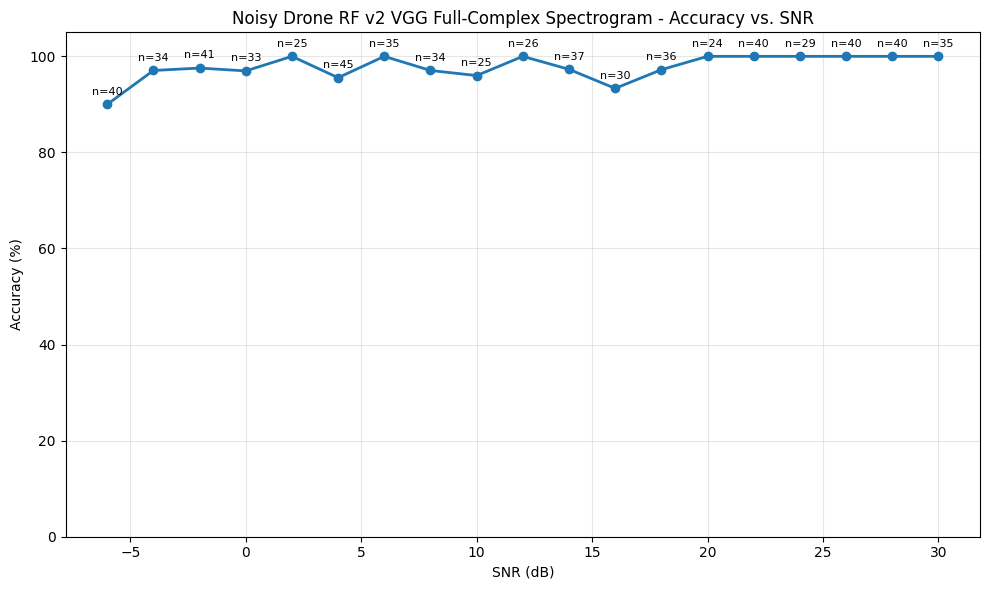

Saved: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/noisy_drone_rf_v2_eval/33_noisy_drone_rf_v2_vgg_full_complex_accuracy_vs_snr_per_class.png


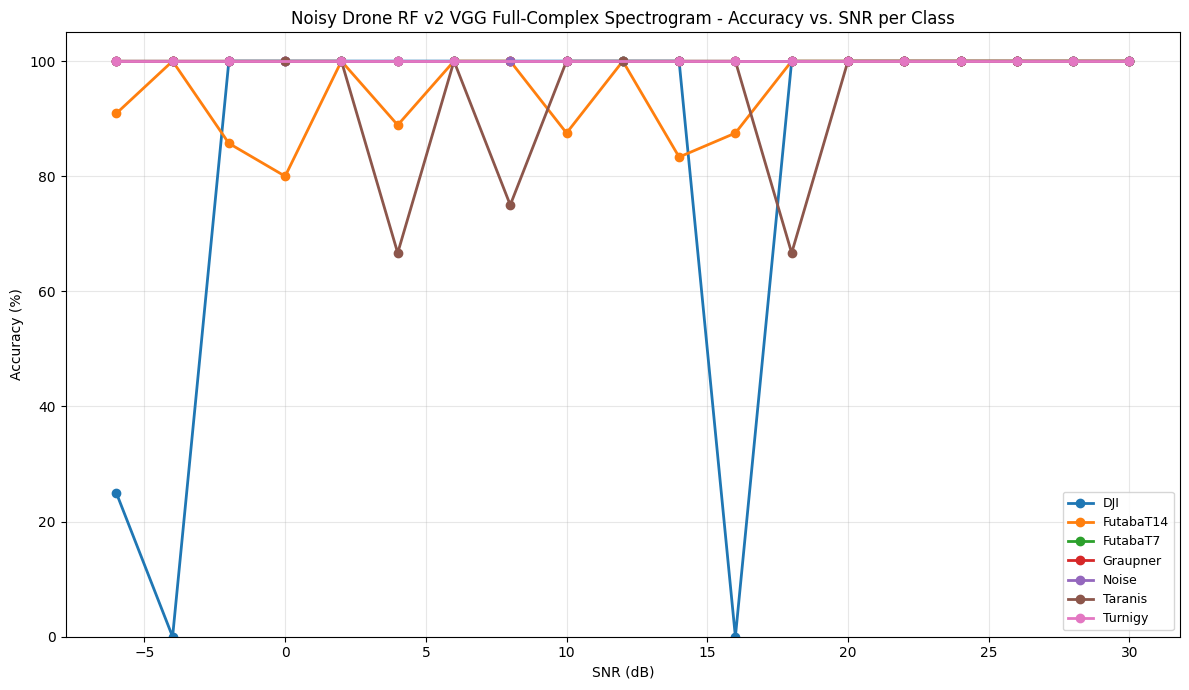

,snr,accuracy,samples,accuracy_pct
0,-6,0.900000,40,90.000000
1,-4,0.970588,34,97.058824
2,-2,0.975610,41,97.560976
3,0,0.969697,33,96.969697
4,2,1.000000,25,100.000000
5,4,0.955556,45,95.555556
6,6,1.000000,35,100.000000
7,8,0.970588,34,97.058824
8,10,0.960000,25,96.000000
9,12,1.000000,26,100.000000


,snr,true_label,accuracy,samples,accuracy_pct
0,-6,DJI,0.25,4,25.0
6,-4,DJI,0.00,1,0.0
13,-2,DJI,1.00,4,100.0
19,0,DJI,1.00,3,100.0
24,2,DJI,1.00,2,100.0
...,...,...,...,...,...
92,22,Turnigy,1.00,2,100.0
99,24,Turnigy,1.00,1,100.0
106,26,Turnigy,1.00,1,100.0
112,28,Turnigy,1.00,1,100.0


: 

In [ ]:
# Cell 4: Plot accuracy across SNR, overall and per class
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import yaml
from tensorflow.keras.models import load_model

# Rebuild project/data/model paths if this cell is run from a fresh kernel.
notebook_dir = Path().resolve()
if notebook_dir.name == 'notebooks':
    project_root = notebook_dir.parent
elif (notebook_dir / 'notebooks').exists() and (notebook_dir / 'src').exists():
    project_root = notebook_dir
elif (notebook_dir / 'ML-wireless-signal-classification').exists():
    project_root = notebook_dir / 'ML-wireless-signal-classification'
else:
    project_root = notebook_dir

cfg_path = project_root / 'configs' / 'local_data_paths.yaml'
if cfg_path.exists():
    local_cfg = yaml.safe_load(cfg_path.read_text())
    dcfg = local_cfg.get('datasets', {}).get('noisy_drone_rf_v2', {})
    data_dir = Path(
        dcfg.get(
            'data_dir',
            Path(local_cfg.get('dataset_root', '/scratch/rameyjm7/datasets')) / 'NoisyDroneRFv2',
        )
    )
else:
    data_dir = Path('/scratch/rameyjm7/datasets/NoisyDroneRFv2')

outputs_dir = project_root / 'outputs' / 'noisy_drone_rf_v2_eval'
model_dir = project_root / 'models' / 'noisy_drone_rf_v2'
outputs_dir.mkdir(parents=True, exist_ok=True)

vgg_best_path = model_dir / 'noisy_drone_rf_v2_vgg_full_complex_spectrogram_best.keras'
vgg_final_path = model_dir / 'noisy_drone_rf_v2_vgg_full_complex_spectrogram_final.keras'
model_path = vgg_final_path if vgg_final_path.exists() else vgg_best_path
if not model_path.exists():
    raise FileNotFoundError(f'Missing VGG model: {model_path}')

# If Cell 1 was not run, define the minimal constants/functions needed for SNR evaluation.
if 'label_names' not in globals():
    label_names = ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Noise', 'Taranis', 'Turnigy']

if 'BATCH_SIZE' not in globals():
    BATCH_SIZE = int(os.getenv('NOISY_DRONE_BATCH_SIZE', '8'))
if 'EVAL_LIMIT' not in globals():
    EVAL_LIMIT = int(os.getenv('NOISY_DRONE_EVAL_LIMIT', '0'))
if 'SPEC_EVAL_WINDOWS' not in globals():
    SPEC_EVAL_WINDOWS = int(os.getenv('NOISY_DRONE_SPEC_EVAL_WINDOWS', '1'))

if 'test_df' not in globals() or 'prepare_spectrogram_windows' not in globals():
    raise RuntimeError(
        'Run Cell 1 first so test_df and prepare_spectrogram_windows are available. '
        'This cell can rebuild paths/model loading, but it still needs Cell 1 data-prep functions.'
    )

vgg_eval_model = load_model(model_path, compile=False)
print('Loaded model:', model_path)

snr_eval_df = test_df.copy()
if EVAL_LIMIT > 0:
    snr_eval_df = snr_eval_df.head(EVAL_LIMIT).copy()

if 'snr' not in snr_eval_df.columns:
    raise ValueError('Expected test_df to include an snr column.')

rows = []
for row in snr_eval_df.itertuples(index=False):
    x = prepare_spectrogram_windows(row.filepath, row.snr, n_windows=SPEC_EVAL_WINDOWS)
    probs = vgg_eval_model.predict(x, batch_size=BATCH_SIZE, verbose=0).mean(axis=0)
    pred_idx = int(np.argmax(probs))
    true_idx = int(row.label_idx)
    rows.append({
        'snr': int(row.snr),
        'true_idx': true_idx,
        'pred_idx': pred_idx,
        'true_label': label_names[true_idx],
        'pred_label': label_names[pred_idx],
        'correct': int(pred_idx == true_idx),
    })

snr_results_df = pd.DataFrame(rows)
snr_results_path = outputs_dir / '33_noisy_drone_rf_v2_vgg_full_complex_snr_results.csv'
snr_results_df.to_csv(snr_results_path, index=False)
print('Saved SNR-level predictions:', snr_results_path)

overall_snr = (
    snr_results_df
    .groupby('snr', as_index=False)
    .agg(accuracy=('correct', 'mean'), samples=('correct', 'size'))
    .sort_values('snr')
)
overall_snr['accuracy_pct'] = overall_snr['accuracy'] * 100.0

per_class_snr = (
    snr_results_df
    .groupby(['snr', 'true_label'], as_index=False)
    .agg(accuracy=('correct', 'mean'), samples=('correct', 'size'))
    .sort_values(['true_label', 'snr'])
)
per_class_snr['accuracy_pct'] = per_class_snr['accuracy'] * 100.0

overall_path = outputs_dir / '33_noisy_drone_rf_v2_vgg_full_complex_accuracy_vs_snr.csv'
per_class_path = outputs_dir / '33_noisy_drone_rf_v2_vgg_full_complex_accuracy_vs_snr_per_class.csv'
overall_snr.to_csv(overall_path, index=False)
per_class_snr.to_csv(per_class_path, index=False)
print('Saved overall SNR accuracy:', overall_path)
print('Saved per-class SNR accuracy:', per_class_path)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(overall_snr['snr'], overall_snr['accuracy_pct'], marker='o', linewidth=2)
ax.set_title('Noisy Drone RF v2 VGG Full-Complex Spectrogram - Accuracy vs. SNR')
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)

for _, rec in overall_snr.iterrows():
    ax.annotate(
        f"n={int(rec['samples'])}",
        (rec['snr'], rec['accuracy_pct']),
        textcoords='offset points',
        xytext=(0, 7),
        ha='center',
        fontsize=8,
    )

plt.tight_layout()
overall_plot_path = outputs_dir / '33_noisy_drone_rf_v2_vgg_full_complex_accuracy_vs_snr.png'
plt.savefig(overall_plot_path, dpi=180)
print('Saved:', overall_plot_path)
plt.show()

fig, ax = plt.subplots(figsize=(12, 7))
for label in label_names:
    label_df = per_class_snr[per_class_snr['true_label'] == label]
    if label_df.empty:
        continue
    ax.plot(
        label_df['snr'],
        label_df['accuracy_pct'],
        marker='o',
        linewidth=2,
        label=label,
    )

ax.set_title('Noisy Drone RF v2 VGG Full-Complex Spectrogram - Accuracy vs. SNR per Class')
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9)

plt.tight_layout()
per_class_plot_path = outputs_dir / '33_noisy_drone_rf_v2_vgg_full_complex_accuracy_vs_snr_per_class.png'
plt.savefig(per_class_plot_path, dpi=180)
print('Saved:', per_class_plot_path)
plt.show()

display(overall_snr)
display(per_class_snr)